Feature Engineering-Handling Missing Data

In [1]:
import seaborn as sns

In [3]:
df = sns.load_dataset('titanic')

In [4]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [6]:
# check missing values
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [7]:
# Delete the rows or data point to handel missing values and this will loose the data this not correct method
df.shape

(891, 15)

In [8]:
df.dropna().shape  # this is bad we are loosing huge amount of data

(182, 15)

# Imputation missing value techinuque
1. Mean Value Imputation

<Axes: xlabel='age', ylabel='Count'>

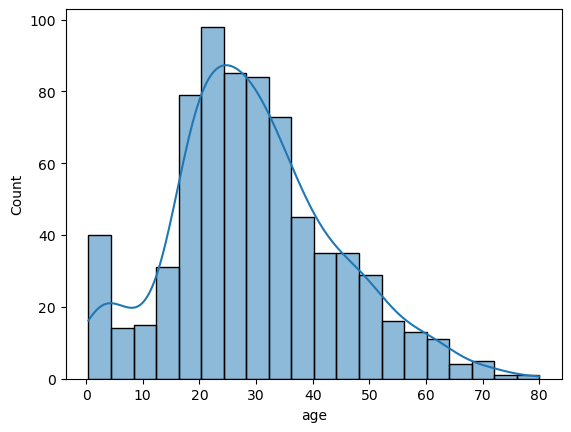

In [10]:
sns.histplot(df['age'],kde=True)

In [11]:
df['Age_Mean']= df['age'].fillna(df['age'].mean())
df[['Age_Mean','age']]

,Age_Mean,age
0,22.000000,22.0
1,38.000000,38.0
2,26.000000,26.0
3,35.000000,35.0
4,35.000000,35.0
...,...,...
886,27.000000,27.0
887,19.000000,19.0
888,29.699118,NaN
889,26.000000,26.0


In [ ]:
# Mean Imputation works well when we have normally distribution

2. Median Value Imputation- If we have outliers in the dataset

In [14]:
df['Age_Median']=df['age'].fillna(df['age'].median())
df[['Age_Median','Age_Mean','age']]

,Age_Median,Age_Mean,age
0,22.0,22.000000,22.0
1,38.0,38.000000,38.0
2,26.0,26.000000,26.0
3,35.0,35.000000,35.0
4,35.0,35.000000,35.0
...,...,...,...
886,27.0,27.000000,27.0
887,19.0,19.000000,19.0
888,28.0,29.699118,NaN
889,26.0,26.000000,26.0


3. Mode Imputation Technique- Categorical values

In [16]:
df[df['embarked'].isnull()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,Age_Mean,Age_Median
61,1,1,female,38.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,38.0,38.0
829,1,1,female,62.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,62.0,62.0


In [17]:
df['embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [21]:
mode_value=df[df['embarked'].notna()]['embarked'].mode()[0]
df['Embarked_Mode']=df['embarked'].fillna(mode_value)
df[['Embarked_Mode','embarked']]

,Embarked_Mode,embarked
0,S,S
1,C,C
2,S,S
3,S,S
4,S,S
...,...,...
886,S,S
887,S,S
888,S,S
889,C,C


Handling Imbalanced Dataset:
Two Technique:
1. Up Sampling
2. Down Sampling

In [1]:
import numpy as np
import pandas as pd

#set random seed for reproducibility
np.random.seed(123)
# Create a  dataframe with tow classes
n_samples=1000
class_0_ratio=0.9
n_class_0=int(n_samples*class_0_ratio)
n_class_1=n_samples - n_class_0
n_class_0, n_class_1

(900, 100)

In [3]:
# Create my dataframe with imbalanced dataset
class_0  = pd.DataFrame({
    'feature1': np.random.normal(loc=0, scale=1, size=n_class_0),
    'feature2': np.random.normal(loc=0, scale=1, size=n_class_0),
    'target': [0] * n_class_0
})
class_1 = pd.DataFrame({
    'feature1': np.random.normal(loc=1, scale=1, size=n_class_1),
    'feature2': np.random.normal(loc=1, scale=1, size=n_class_1),
    'target': [1] * n_class_1
})

# Combine the two classes into a single dataframe
df = pd.concat([class_0, class_1]).reset_index(drop=True)

df.head()


,feature1,feature2,target
0,-1.774224,0.285744,0
1,-1.201377,0.333279,0
2,1.096257,0.531807,0
3,0.861037,-0.354766,0
4,-1.520367,-1.120815,0


In [4]:
df['target'].value_counts() # this is imbalanced dataset

target
0    900
1    100
Name: count, dtype: int64

In [5]:
# upsampling 
df_minority = df[df['target']==1] # this is minority class
df_majority = df[df['target']==0] # this is majority class



In [6]:
from sklearn.utils import resample
df_minority_upsample=resample(df_minority, replace=True, #Sample with replace
         n_samples=len(df_majority),
         random_state=42
    )


In [7]:
df_minority_upsample.shape

(900, 3)

In [8]:
df_minority_upsample.head()

,feature1,feature2,target
951,1.905343,0.495151,1
992,1.000977,0.814833,1
914,0.927957,1.280911,1
971,1.819483,1.964646,1
960,1.456515,0.833528,1


In [10]:
df_upsampled= pd.concat([df_majority, df_minority_upsample])
df_upsampled['target'].value_counts()

target
0    900
1    900
Name: count, dtype: int64

not create downsampling

SMOTE(Syntheic Minority Oversampling Technique):


Is a technique used in ML to address imbalanced datasets where the minority class has significantly fewer instance than the majority class. SMOTE involves generating synthetic instance of the minority class by interpolating between existing insatance.

In [2]:
from sklearn.datasets import make_classification


In [6]:
x, y = make_classification(n_samples=1000, n_redundant=0, n_features=2, n_clusters_per_class=1, weights=[0.90], random_state=12)

In [12]:
import pandas as pd
df1 = pd.DataFrame(x, columns=['f1', 'f2'])
df2 = pd.DataFrame(y, columns=['target'])
final_df = pd.concat([df1, df2], axis=1)
final_df.head()

,f1,f2,target
0,-0.762898,-0.706808,0
1,-1.075436,-1.051162,0
2,-0.610115,-0.909802,0
3,-2.023284,-0.428945,1
4,-0.812921,-1.316206,0


In [13]:
final_df['target'].value_counts() # this is imbalanced dataset

target
0    900
1    100
Name: count, dtype: int64

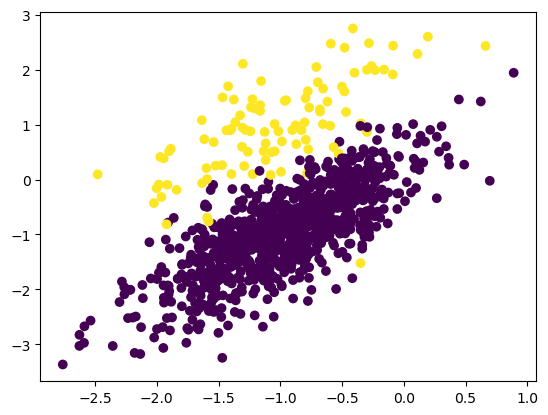

In [14]:
import matplotlib.pyplot as plt
plt.scatter(final_df['f1'], final_df['f2'], c=final_df['target'])

In [ ]:
pip install imblearn

In [11]:
from imblearn.over_sampling import SMOTE

In [15]:
# transform the dataset
oversampler = SMOTE()
x,y = oversampler.fit_resample(final_df[['f1', 'f2']], final_df['target'])

In [16]:
x.shape

(1800, 2)

In [17]:
y.shape

(1800,)

In [18]:
df1 = pd.DataFrame(x, columns=['f1', 'f2'])
df2 = pd.DataFrame(y, columns=['target'])
oversample_df = pd.concat([df1, df2], axis=1)

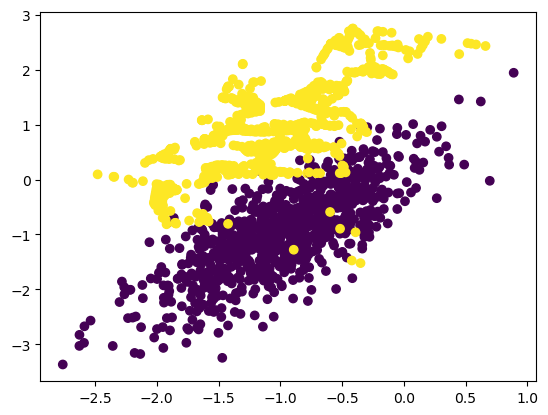

In [19]:
plt.scatter(oversample_df['f1'], oversample_df['f2'], c=oversample_df['target'])